In [12]:
from diffusion_models.models import diffusion as dd
import diffusion_models.utils.common_logging as cl
import numpy as np
from diffusion_models.utils import common_utils as ut
import pandas as pd
import os
import pymc as pm
from pytensor import tensor as at

In [13]:
(0.2515518 + 2*0.0008319) * np.exp( ((0.2515518 + 2*0.0008319)**2) / (2*0.0008319) )

1.3802884675754678e+16

In [14]:
v, a, z, t_er, lp_v, X, RT = dd._test_likelihood_using_prior(100, 20)

2023-01-17 11:55:50,826 - diffusion - DEBUG - Starting Diffusion test


DEBUG:diffusion:Starting Diffusion test


v __str__ = [[-2.9678563  -2.9678563  -4.44763576 ... -2.9678563  -4.44763576
  -4.44763576]
 [ 2.23758393  2.23758393  2.23758393 ... -4.4759994   2.23758393
  -4.4759994 ]
 [-4.04012561 -4.04012561 -4.04012561 ...  5.18114907 -4.04012561
  -4.04012561]
 ...
 [-2.03689192 -2.03689192 -2.03689192 ... -4.63175564 -2.03689192
  -4.63175564]
 [-3.56114917 -0.65488066 -0.65488066 ... -0.65488066 -0.65488066
  -0.65488066]
 [ 3.84507329  3.84507329  3.84507329 ... -3.36775697 -3.36775697
  -3.36775697]]
a __str__ = [[173.72738036 173.72738036   3.08719348 ... 173.72738036   3.08719348
    3.08719348]
 [ 35.95277427  35.95277427  35.95277427 ...   2.32714842  35.95277427
    2.32714842]
 [  7.42015903   7.42015903   7.42015903 ...  46.19908539   7.42015903
    7.42015903]
 ...
 [ 97.80046388  97.80046388  97.80046388 ...   0.46988226  97.80046388
    0.46988226]
 [  5.33211277  49.3773345   49.3773345  ...  49.3773345   49.3773345
   49.3773345 ]
 [ 22.3754158   22.3754158   22.3754158  ... 

DEBUG:diffusion:lp: [[1.92567010e+137 1.31829563e+137 2.11572513e-006 ... 3.70013956e+137
  4.19678544e-008 3.19580497e-001]
 [1.74361507e-019 8.55621377e-020 1.02958472e-021 ... 4.95248739e-005
  9.98589971e-020 2.66004716e+003]
 [7.09295046e+002 1.90743053e+002 6.10547867e+005 ... 1.84093730e-062
  5.23423389e-003 1.61266350e-003]
 ...
 [9.10057138e+052 2.50054875e+054 4.95036499e+053 ... 4.39835699e-005
  6.94046348e+051 4.37764907e-001]
 [2.52628079e+004 1.12362730e+011 7.71136563e+010 ... 6.04797670e+010
  8.90666521e+010 7.26243905e+010]
 [2.91895680e-030 2.36807685e-034 7.30886578e-039 ... 4.42937647e+002
  2.20192922e-001 1.75202018e-001]]


2023-01-17 11:55:52,390 - diffusion - DEBUG - X:[[0 0 1 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [1 1 1 ... 0 1 1]
 ...
 [0 0 0 ... 1 0 1]
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 1 1 1]]


DEBUG:diffusion:X:[[0 0 1 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [1 1 1 ... 0 1 1]
 ...
 [0 0 0 ... 1 0 1]
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 1 1 1]]


2023-01-17 11:55:52,424 - diffusion - DEBUG - RT:[[3.22664692 3.36322551 2.89751555 ... 3.07814649 3.33323415 1.71753394]
 [1.11041526 1.77287233 3.42597012 ... 2.5087683  1.75412709 0.5474637 ]
 [1.44608171 1.63427629 0.21172346 ... 2.06033076 2.93444194 3.06217779]
 ...
 [2.27166046 0.78174633 1.4266823  ... 2.0160739  3.67140146 1.17616111]
 [0.24964691 1.70631561 2.14801069 ... 3.5527638  3.29158845 3.61449545]
 [1.30514788 2.6094869  3.97633971 ... 1.41721852 2.81695409 2.83348104]]


DEBUG:diffusion:RT:[[3.22664692 3.36322551 2.89751555 ... 3.07814649 3.33323415 1.71753394]
 [1.11041526 1.77287233 3.42597012 ... 2.5087683  1.75412709 0.5474637 ]
 [1.44608171 1.63427629 0.21172346 ... 2.06033076 2.93444194 3.06217779]
 ...
 [2.27166046 0.78174633 1.4266823  ... 2.0160739  3.67140146 1.17616111]
 [0.24964691 1.70631561 2.14801069 ... 3.5527638  3.29158845 3.61449545]
 [1.30514788 2.6094869  3.97633971 ... 1.41721852 2.81695409 2.83348104]]


2023-01-17 11:55:52,425 - diffusion - INFO - Test Successful!


INFO:diffusion:Test Successful!


In [15]:
lp_v.shape

(100, 20)

In [16]:
df = pd.DataFrame({"p":lp_v.flatten(), "lp":np.log(lp_v.flatten() + 0.0001), "RT":RT.flatten()})
df

,p,lp,RT
0,1.925670e+137,316.109432,3.226647
1,1.318296e+137,315.730497,3.363226
2,2.115725e-06,-9.189404,2.897516
3,2.225862e+136,313.951717,3.763621
4,2.063420e-10,-9.210338,3.884171
...,...,...,...
1995,1.153827e-02,-4.453456,3.326512
1996,1.245241e-32,-9.210340,2.056150
1997,4.429376e+02,6.093429,1.417219
1998,2.201929e-01,-1.512797,2.816954


<AxesSubplot: xlabel='RT', ylabel='lp'>

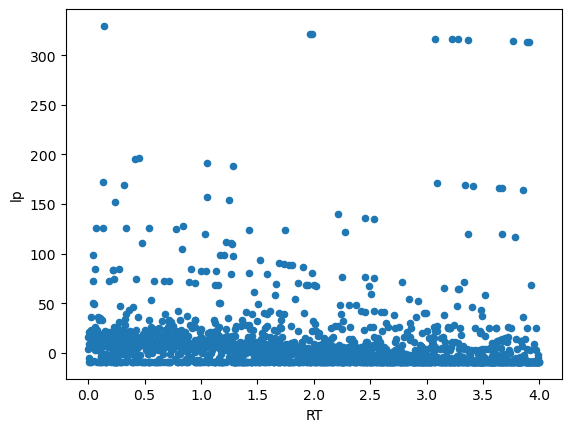

In [17]:
df.plot(x="RT", y="lp", kind="scatter")

<AxesSubplot: >

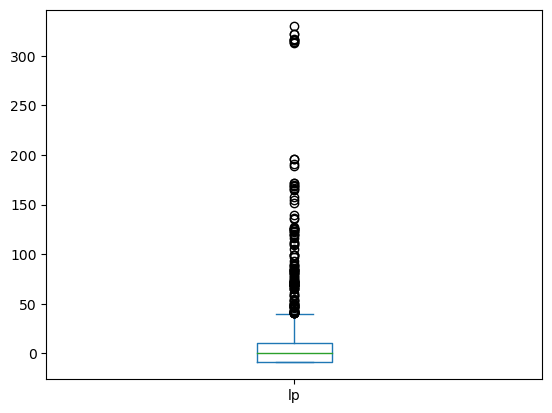

In [18]:
df.loc[:,"lp"].plot(kind="box")

In [19]:
np.save("v.npy",v)
np.save("a.npy",a)
np.save("z.npy",z)
np.save("t_er.npy",t_er)
np.save("X.npy",X)
np.save("RT.npy",RT)

In [20]:
#prior_chain = dd.sample_prior_data(10,2,9)

In [21]:
#post_chain = dd.sample_posterior_params(RT, X, 10,2,10)


In [22]:
from numpy import *
for i in range(100):
    print(exp(-i) * sin(i), end=" ")

0.0 0.3095598756531122 0.12306002480577674 0.00702595148935012 -0.013861321214152955 -0.006461180938816702 -0.0006926017743549024 0.0005990942309826656 0.0003318927173493011 5.085946152418432e-05 -2.469852022368637e-05 -1.6701537222985805e-05 -3.296817951239637e-06 9.49715909183348e-07 8.23718465615528e-07 1.9892455929818242e-07 -3.2399250043157306e-08 -3.980125739377633e-08 -1.1437520556870132e-08 8.397314963676155e-10 1.8817204106253274e-09 6.343991936552866e-10 -2.4690444845695894e-12 -8.683811929535725e-11 -3.418680156962888e-11 -1.838093675787618e-12 3.895979012602309e-12 1.7975361168805825e-12 1.8731510116466498e-13 -1.68806271370784e-13 -9.245627419551825e-14 -1.390890344984763e-14 6.983358779432353e-15 4.658475511378314e-15 9.067992767240052e-16 -2.6997417258446606e-16 -2.3004536931140983e-16 -5.4913415409177125e-17 9.303403239592989e-18 1.113012517772699e-17 3.165504665996206e-18 -2.479085438996624e-19 -5.269561045445734e-19 -1.759312574418081e-19 1.3774102016786937e-21 2.4357